# Create Training Progress GIFs

This notebook builds two GIFs from `images/train`:
- training progression by epoch
- final sampling progression across ODE steps


In [1]:
from pathlib import Path
import re

from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as IPyImage, display

TRAIN_DIR = Path('../images/train')
OUT_DIR = TRAIN_DIR

EPOCH_GIF = OUT_DIR / 'training_by_epoch.gif'
ODE_GIF = OUT_DIR / 'sampling_ode_steps.gif'

print(f'Train dir: {TRAIN_DIR.resolve()}')


Train dir: /Users/Luke.Padmore/Source/flow-matching-mnist/images/train


In [2]:
def sorted_frames(pattern: str, extract_int):
    paths = list(TRAIN_DIR.glob(pattern))
    return sorted(paths, key=extract_int)


def parse_epoch(path: Path) -> int:
    m = re.search(r'epoch_(\d+)\.png$', path.name)
    if not m:
        raise ValueError(f'Cannot parse epoch from {path.name}')
    return int(m.group(1))


def parse_ode_step(path: Path) -> int:
    m = re.search(r'ode_step_(\d+)\.png$', path.name)
    if not m:
        raise ValueError(f'Cannot parse ODE step from {path.name}')
    return int(m.group(1))


def annotate_frame(image_path: Path, lines: list[str]) -> Image.Image:
    img = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(img, 'RGBA')
    font = ImageFont.load_default()

    left = 6
    top = 6
    line_h = 12
    box_h = 8 + line_h * len(lines)
    box_w = max(120, max(draw.textlength(line, font=font) for line in lines) + 12)

    draw.rectangle((left, top, left + box_w, top + box_h), fill=(0, 0, 0, 150))
    y = top + 4
    for line in lines:
        draw.text((left + 6, y), line, fill=(255, 255, 255, 255), font=font)
        y += line_h

    return img


def save_gif(frames: list[Image.Image], out_path: Path, duration_ms: int, loop: int = 0) -> None:
    if not frames:
        raise ValueError('No frames to save.')
    frames[0].save(
        out_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=loop,
        optimize=False,
    )


In [3]:
# GIF 1: Training progression by epoch
epoch_paths = sorted_frames('epoch_*.png', parse_epoch)
epoch_frames = [
    annotate_frame(path, [f'Epoch: {parse_epoch(path)}'])
    for path in epoch_paths
]
save_gif(epoch_frames, EPOCH_GIF, duration_ms=450)

print(f'Saved {len(epoch_frames)} frames to {EPOCH_GIF.resolve()}')


Saved 10 frames to /Users/Luke.Padmore/Source/flow-matching-mnist/images/train/training_by_epoch.gif


In [4]:
# GIF 2: ODE sampling progression (0..50 steps) with epoch + step annotation
ode_paths_all = sorted_frames('final_sample_ode_step_*.png', parse_ode_step)
ode_paths = [p for p in ode_paths_all if parse_ode_step(p) <= 50]

# Use the highest logged epoch as the 'final' epoch label
final_epoch = max(parse_epoch(p) for p in epoch_paths) if epoch_paths else -1

ode_frames = [
    annotate_frame(path, [f'Epoch: {final_epoch}', f'ODE step: {parse_ode_step(path)}/50'])
    for path in ode_paths
]
save_gif(ode_frames, ODE_GIF, duration_ms=120)

print(f'Saved {len(ode_frames)} frames to {ODE_GIF.resolve()}')


Saved 51 frames to /Users/Luke.Padmore/Source/flow-matching-mnist/images/train/sampling_ode_steps.gif


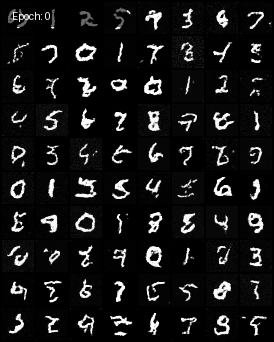

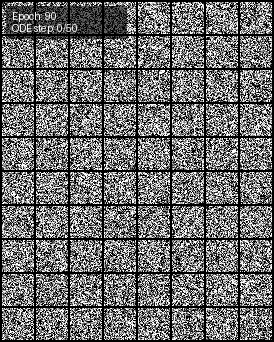

In [5]:
# Preview
display(IPyImage(filename=str(EPOCH_GIF)))
display(IPyImage(filename=str(ODE_GIF)))
